## 1. Import optimization libraries and verify upstream evidence


In [1]:
import sys
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import Bounds, LinearConstraint, milp
from scipy.sparse import lil_matrix

sys.path.insert(0, "..")
from common_metrics import require, fairness_metrics, gini

DATA_DIR = Path("output")

from validation import verify_stage, validate_schedule
for upstream in range(3):
    verify_stage(upstream)


## 2. Load canonical data and notebook 02 specification


In [2]:
def first_existing(paths):
    for path in paths:
        if Path(path).is_file():
            return Path(path)
    return None


canonical_path = first_existing([DATA_DIR / "canonical_schedule.csv", "canonical_schedule.csv"])
specification_path = first_existing([DATA_DIR / "model_specification.json", "model_specification.json"])
require(canonical_path is not None and specification_path is not None, "Run notebooks 00-02 first.")

canonical_sha256 = hashlib.sha256(canonical_path.read_bytes()).hexdigest()
model_specification = json.loads(specification_path.read_text(encoding="utf-8"))


require(canonical_sha256 == model_specification.get("canonical_sha256"),
        "The specification was produced from a different canonical_schedule.csv file.")

historical = pd.read_csv(canonical_path)
for column in ["source_row", "nT", "rotation_group", "rotation_round"]:
    historical[column] = pd.to_numeric(historical[column], errors="raise").astype(int)
historical["week_start"] = pd.to_datetime(historical["week_start"], errors="raise")
historical["week_end"] = pd.to_datetime(historical["week_end"], errors="raise")

pharmacies = sorted(historical["pharmacy_id"].unique())
weeks = (
    historical[["week_id", "week_start", "week_end", "nT", "rotation_group", "rotation_round"]]
    .drop_duplicates().sort_values("week_start").reset_index(drop=True)
)

parameters = model_specification["parameters"]
derived_maps = model_specification["derived_maps"]
rotation_groups = [int(g) for g in parameters["rotation_groups"]]
weekly_staffing_floor = int(parameters["weekly_staffing_floor"])
weekly_h24_required = int(parameters["weekly_h24_required"])
maximum_annual_workload = int(parameters["maximum_annual_workload"])
h24_cycle_bounds_by_group = {int(g): {k: int(v) for k, v in b.items()} for g, b in parameters["h24_cycle_bounds_by_group"].items()}
group_by_nt = {int(nt): int(g) for nt, g in derived_maps["group_by_nt"].items()}
primary_group = {p: int(g) for p, g in derived_maps["primary_group_by_pharmacy"].items()}
nt_occurrences = {int(nt): int(c) for nt, c in derived_maps["nt_occurrences"].items()}
nt_values = sorted(nt_occurrences)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 150)
print("Assignments / weeks / rotating pharmacies:", len(historical), len(weeks), len(pharmacies))
print(f"Weekly staffing floor = {weekly_staffing_floor}  "
      f"[{model_specification['parameter_status']['weekly_staffing_floor']['classification']}]")


Assignments / weeks / rotating pharmacies: 931 53 123
Weekly staffing floor = 17  [HISTORICAL_PROXY_UNVALIDATED]


## 3. Build the MILP from the verified specification


In [3]:
weeks_by_nt = weeks.groupby("nT")["week_id"].apply(list).to_dict()



eligible_patterns = [
    (pharmacy_id, nt) for nt in nt_values for pharmacy_id in pharmacies
    if primary_group[pharmacy_id] == group_by_nt[nt]
]
pattern_index = {pair: i for i, pair in enumerate(eligible_patterns)}
pattern_count = len(eligible_patterns)


y_offset, h_offset = 0, pattern_count
max_total_index, min_total_index = 2 * pattern_count, 2 * pattern_count + 1
max_h24_index, min_h24_index = 2 * pattern_count + 2, 2 * pattern_count + 3
variable_count = 2 * pattern_count + 4

lower_bounds = np.zeros(variable_count)
upper_bounds = np.ones(variable_count)
upper_bounds[[max_total_index, min_total_index, max_h24_index, min_h24_index]] = maximum_annual_workload
integrality = np.ones(variable_count)
integrality[-4:] = 0
solver_log = []
base_rows = []


def add_row(coefficients, lower=-np.inf, upper=np.inf):
    '''Register one linear constraint row: lower <= sum(coef * variable) <= upper.'''
    base_rows.append((coefficients, lower, upper))




for nt in nt_values:
    indices = [pattern_index[(p, nt)] for p in pharmacies if (p, nt) in pattern_index]
    add_row({y_offset + i: 1 for i in indices}, weekly_staffing_floor, np.inf)
    add_row({h_offset + i: 1 for i in indices}, weekly_h24_required, weekly_h24_required)

for i in range(pattern_count):
    add_row({h_offset + i: 1, y_offset + i: -1}, -np.inf, 0)  




pharmacy_indices = {}
for pharmacy_id in pharmacies:
    indices = [i for (p, _), i in pattern_index.items() if p == pharmacy_id]
    pharmacy_indices[pharmacy_id] = indices
    total_coef = {y_offset + i: nt_occurrences[eligible_patterns[i][1]] for i in indices}
    h24_coef = {h_offset + i: nt_occurrences[eligible_patterns[i][1]] for i in indices}
    cycle_h24_coef = {h_offset + i: 1 for i in indices}
    bounds = h24_cycle_bounds_by_group[primary_group[pharmacy_id]]

    add_row(total_coef, -np.inf, maximum_annual_workload)
    add_row({**total_coef, max_total_index: -1}, -np.inf, 0)   
    add_row({**total_coef, min_total_index: -1}, 0, np.inf)    
    add_row({**h24_coef, max_h24_index: -1}, -np.inf, 0)
    add_row({**h24_coef, min_h24_index: -1}, 0, np.inf)
    add_row(cycle_h24_coef, bounds["minimum"], bounds["maximum"])


def solve_model(extra_rows, objective, label):
    rows = base_rows + list(extra_rows)
    matrix = lil_matrix((len(rows), variable_count), dtype=float)
    row_lower, row_upper = np.empty(len(rows)), np.empty(len(rows))
    for r, (coefficients, lower, upper) in enumerate(rows):
        for column, value in coefficients.items():
            matrix[r, column] = value
        row_lower[r], row_upper[r] = lower, upper
    result = milp(
        c=np.asarray(objective, dtype=float), integrality=integrality,
        bounds=Bounds(lower_bounds, upper_bounds),
        constraints=LinearConstraint(matrix.tocsr(), row_lower, row_upper),
        options={"mip_rel_gap": 0.0},
    )
    require(result.success, f"{label} failed: {result.message}")
    require(np.max(np.abs(result.x[:2*pattern_count] - np.rint(result.x[:2*pattern_count]))) < 1e-6, "Nonintegral binary solution.")
    values = matrix.tocsr() @ result.x
    require(np.all(values >= row_lower - 1e-6) and np.all(values <= row_upper + 1e-6), "Solver constraint residual.")
    solver_log.append({"label":label,"status":int(result.status),"objective":float(result.fun),
                       "dual_bound":float(result.mip_dual_bound),"mip_gap":float(result.mip_gap)})
    return result


def lock_objective(rows, objective, result):
    '''Freeze the just-found optimum as an equality constraint, so the next solve in a
    lexicographic chain can optimize a lower-priority objective without undoing it.'''
    value = float(np.dot(objective, result.x))
    require(abs(value - round(value)) < 1e-6, "Cannot round a noninteger lexicographic objective.")
    optimum = int(round(value))
    rows.append(({i: float(v) for i, v in enumerate(objective) if v != 0}, optimum, optimum))
    return optimum


historical_active = set(zip(historical["pharmacy_id"], historical["week_id"]))
historical_h24 = set(zip(
    historical.loc[historical["shift_type"].eq("H24"), "pharmacy_id"],
    historical.loc[historical["shift_type"].eq("H24"), "week_id"],
))




total_objective = np.zeros(variable_count)
active_change_objective = np.zeros(variable_count)
h24_change_objective = np.zeros(variable_count)
for (pharmacy_id, nt), i in pattern_index.items():
    occurrences = nt_occurrences[nt]
    total_objective[y_offset + i] = occurrences
    active_present = sum((pharmacy_id, w) in historical_active for w in weeks_by_nt[nt])
    h24_present = sum((pharmacy_id, w) in historical_h24 for w in weeks_by_nt[nt])
    active_change_objective[y_offset + i] = occurrences - 2 * active_present
    h24_change_objective[h_offset + i] = occurrences - 2 * h24_present

total_range_objective = np.zeros(variable_count)
total_range_objective[[max_total_index, min_total_index]] = [1, -1]
h24_range_objective = np.zeros(variable_count)
h24_range_objective[[max_h24_index, min_h24_index]] = [1, -1]

print("Eligible pattern pairs:", pattern_count)


Eligible pattern pairs: 738


## 4. Solve lexicographic scenarios


In [4]:

objectives = {"assignments":total_objective,"total_range":total_range_objective,
              "h24_range":h24_range_objective,"active_stability":active_change_objective,
              "h24_stability":h24_change_objective}
def solve_scenario(name):
    policy = model_specification["scenario_policies"][name]
    rows = [({y_offset+i:1},1,1) for i in range(pattern_count)] if policy["all_eligible_active"] else []
    for j,key in enumerate(policy["priorities"]):
        result = solve_model(rows,objectives[key],f"{name}: {key}")
        if j < len(policy["priorities"])-1:lock_objective(rows,objectives[key],result)
    return result

efficiency_solution=solve_scenario("Efficiency-first")
fairness_solution=solve_scenario("Fairness-aware")
full_group_solution=solve_scenario("Full-group")


def solution_ranges(solution):
    active = np.rint(solution.x[y_offset:y_offset + pattern_count]).astype(int)
    h24 = np.rint(solution.x[h_offset:h_offset + pattern_count]).astype(int)
    totals, h24s = [], []
    for pharmacy_id in pharmacies:
        indices = pharmacy_indices[pharmacy_id]
        totals.append(sum(active[i] * nt_occurrences[eligible_patterns[i][1]] for i in indices))
        h24s.append(sum(h24[i] * nt_occurrences[eligible_patterns[i][1]] for i in indices))
    return int(max(totals) - min(totals)), int(max(h24s) - min(h24s))


solve_summary = pd.DataFrame([
    ("Efficiency-first", int(round(np.dot(total_objective, efficiency_solution.x))), *solution_ranges(efficiency_solution)),
    ("Fairness-aware", int(round(np.dot(total_objective, fairness_solution.x))), *solution_ranges(fairness_solution)),
    ("Full-group", int(round(np.dot(total_objective, full_group_solution.x))), *solution_ranges(full_group_solution)),
], columns=["scenario", "assignments", "total_range", "h24_range"])
display(solve_summary)


,scenario,assignments,total_range,h24_range
0,Efficiency-first,901,3,1
1,Fairness-aware,923,1,1
2,Full-group,931,1,1


## 5. Materialize schedules


In [5]:



access_mode_map = historical.groupby("pharmacy_id")["access_mode"].first().to_dict()
primary_location_map = (
    historical.groupby(["pharmacy_id", "location_id"]).size().rename("count").reset_index()
    .sort_values(["pharmacy_id", "count", "location_id"], ascending=[True, False, True])
    .drop_duplicates("pharmacy_id").set_index("pharmacy_id")["location_id"].to_dict()
)
nt_location_map = (
    historical.groupby(["pharmacy_id", "nT", "location_id"]).size().rename("count").reset_index()
    .sort_values(["pharmacy_id", "nT", "count", "location_id"], ascending=[True, True, False, True])
    .drop_duplicates(["pharmacy_id", "nT"]).set_index(["pharmacy_id", "nT"])["location_id"].to_dict()
)


def extract_schedule(solution, source_label):
    '''Turn a solved MILP vector back into one row per (week, pharmacy) -- expanding each
    active pattern out to every calendar week that shares its nT.'''
    active = np.rint(solution.x[y_offset:y_offset + pattern_count]).astype(int)
    h24 = np.rint(solution.x[h_offset:h_offset + pattern_count]).astype(int)
    rows = []
    for (pharmacy_id, nt), i in pattern_index.items():
        if active[i] != 1:
            continue
        location_id = nt_location_map.get((pharmacy_id, nt), primary_location_map[pharmacy_id])
        for _, week in weeks.loc[weeks["nT"].eq(nt)].iterrows():
            rows.append({
                "week_id": week["week_id"], "week_start": week["week_start"], "week_end": week["week_end"],
                "nT": nt, "rotation_group": int(week["rotation_group"]), "rotation_round": int(week["rotation_round"]),
                "pharmacy_id": pharmacy_id, "location_id": location_id,
                "shift_type": "H24" if h24[i] == 1 else "STANDARD", "access_mode": access_mode_map[pharmacy_id],
            })
    output = pd.DataFrame(rows).sort_values(["week_start", "shift_type", "pharmacy_id"]).reset_index(drop=True)
    output.insert(0, "assignment_id", [f"O{i:06d}" for i in range(1, len(output) + 1)])
    output["schedule_source"] = source_label
    return output


efficiency_schedule = extract_schedule(efficiency_solution, "optimized_efficiency_first")
fairness_schedule = extract_schedule(fairness_solution, "optimized_fairness_aware")
full_group_schedule = extract_schedule(full_group_solution, "optimized_full_group")
print("Assignments:", {"Efficiency-first": len(efficiency_schedule), "Fairness-aware": len(fairness_schedule), "Full-group": len(full_group_schedule)})


Assignments: {'Efficiency-first': 901, 'Fairness-aware': 923, 'Full-group': 931}


## 6. Compare historical and optimized scenarios


,assignments,reduction_vs_history,total_min,total_max,total_range,total_jain,total_gini,h24_min,h24_max,h24_range,h24_jain,h24_gini,active_calendar_decision_changes,h24_calendar_decision_changes
scenario,,,,,,,,,,,,,,
Historical,931,0,6,8,2,0.9955,0.0333,0,3,3,0.8672,0.1761,0,0
Efficiency-first,901,30,5,8,3,0.9885,0.0541,1,2,1,0.8898,0.1601,32,6
Fairness-aware,923,8,7,8,1,0.9956,0.0333,1,2,1,0.8898,0.1601,10,6
Full-group,931,0,7,8,1,0.9957,0.0324,1,2,1,0.8898,0.1601,2,6


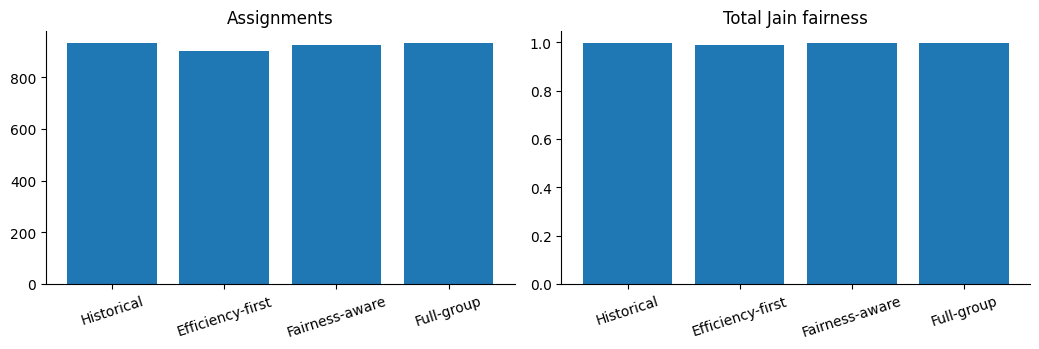

In [6]:
def profile(data):
    result = pd.DataFrame(index=pd.Index(pharmacies, name="pharmacy_id"))
    result["total"] = data.groupby("pharmacy_id").size().reindex(pharmacies, fill_value=0)
    result["h24"] = data.loc[data["shift_type"].eq("H24")].groupby("pharmacy_id").size().reindex(pharmacies, fill_value=0)
    return result


scenario_data = {
    "Historical": historical, "Efficiency-first": efficiency_schedule,
    "Fairness-aware": fairness_schedule, "Full-group": full_group_schedule,
}
rows = []
for name, data in scenario_data.items():
    p = profile(data)
    total, h24 = fairness_metrics(p["total"]), fairness_metrics(p["h24"])
    rows.append({
        "scenario": name, "assignments": len(data), "reduction_vs_history": len(historical) - len(data),
        "total_min": total["minimum"], "total_max": total["maximum"], "total_range": total["range"],
        "total_jain": total["jain_index"], "total_gini": total["gini"],
        "h24_min": h24["minimum"], "h24_max": h24["maximum"], "h24_range": h24["range"],
        "h24_jain": h24["jain_index"], "h24_gini": h24["gini"],
        "active_calendar_decision_changes":len(set(zip(data.pharmacy_id,data.week_id)) ^ historical_active),
        "h24_calendar_decision_changes":len(set(zip(data.loc[data.shift_type.eq("H24"),"pharmacy_id"],data.loc[data.shift_type.eq("H24"),"week_id"])) ^ historical_h24),
    })
scenario_summary = pd.DataFrame(rows).set_index("scenario")
display(scenario_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
order = list(scenario_data)
axes[0].bar(order, scenario_summary.loc[order, "assignments"])
axes[0].set_title("Assignments"); axes[0].tick_params(axis="x", rotation=18)
axes[1].bar(order, scenario_summary.loc[order, "total_jain"])
axes[1].set_title("Total Jain fairness"); axes[1].tick_params(axis="x", rotation=18)
for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


## 7. Save outputs


In [7]:
fairness_schedule.to_csv(DATA_DIR / "optimized_schedule_fairness_aware.csv", index=False)
scenario_summary.to_csv(DATA_DIR / "optimization_scenario_summary.csv")
Path(DATA_DIR / "applied_model_specification.json").write_text(
    json.dumps(model_specification, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("Saved: output/optimized_schedule_fairness_aware.csv, optimization_scenario_summary.csv, applied_model_specification.json")
print("Scope: staffing, rotation and fairness; geography is outside project scope.")

from validation import validate_schedule
for data, name in [(efficiency_schedule,"efficiency_first"),(fairness_schedule,"fairness_aware"),(full_group_schedule,"full_group")]:
    validate_schedule(data, historical, model_specification)
    data.to_csv(DATA_DIR / f"optimized_schedule_{name}.csv", index=False)
(DATA_DIR / "solver_evidence.json").write_text(json.dumps(solver_log, indent=2))

from validation import write_stage
write_stage(3, ['output/stage_00_manifest.json', 'output/stage_01_manifest.json', 'output/stage_02_manifest.json'], ['output/optimized_schedule_fairness_aware.csv', 'output/optimized_schedule_efficiency_first.csv', 'output/optimized_schedule_full_group.csv', 'output/optimization_scenario_summary.csv', 'output/applied_model_specification.json', 'output/solver_evidence.json'])


Saved: output/optimized_schedule_fairness_aware.csv, optimization_scenario_summary.csv, applied_model_specification.json
Scope: staffing, rotation and fairness; geography is outside project scope.
